# framediff v2 — Temporal Features for 3-Class Maneuver Prediction

**Temporal / motion feature extractor for the final 3-class task** (`straight`,
`left-turn`, `right-turn`). Produces the **Trend + Flow** feature set that is the
best-performing model in the project.

**Where it sits in the pipeline**
Runs after `waymo_feature_extraction.ipynb` (base features) and feeds
`feature_pipeline_v3_3class.ipynb`, which concatenates these temporal features with the
static ones for the final benchmark.

**Inputs** (`data/processed/waymo_e2e/features/`): `hog.npy`, `hsv.npy`, `yolo.npy` (base
arrays, re-aligned to the 3-class order via `_load_and_align`), `seq_ids_3class.npy`,
`labels_3class.npy`; plus `ipm_3class.npy` and `bev_corridor_3class.npy` for the optional
IPM/BEV combination benchmark. Reads the per-sequence context frames from the `.npz` cache
for optical flow.

**Outputs** (row-aligned to `seq_ids_3class`): `framediff_v2_3c_aligned.npy` (22 dims),
`framediff_v2_trend_3c.npy` (10 dims), `framediff_v2_flow_3c.npy` (12 dims), and
`framediff_v2_valid_3c.npy` (bool mask, `True` where `n_context ≥ 2`).

**Feature output (22 dims / sequence):**
- **Trend (10):** `[slope_q × 5] + [last_q × 5]` — linear trend across the context window of
  road/VP/YOLO quantities (`road_centroid_x`, `road_area_frac`, `vp_x`, `det_mean_x`,
  `det_lr_balance`).
- **Flow (12):** `[mean_flow × 6] + [last_flow × 6]` — dense Farneback optical flow between
  consecutive context-frame pairs (magnitude, bottom-strip speed, L/R asymmetry, net x / y).

**Result:** **Trend + Flow / Random Forest ≈ 0.65 accuracy, 0.59 macro-F1** on the 3-class
task (majority-class baseline 0.46) — the strongest model in the project, ahead of the best
static-feature set (HOG / SVM ≈ 0.60). The cumulative explained-variance chart at the end of
this notebook is mirrored by `dimensionality_reduction_analysis.ipynb`.

**What's new vs the original (`archive/framediff.ipynb`):** 3-class throughout (lane-change
cells dropped); optical flow magnitude + direction asymmetry added as a speed/heading proxy;
graceful degradation for sequences with `n_context == 1`; canonical v1 functions consistent
with `feature_pipeline_v3_3class.ipynb`; full QA + semantic checks + benchmark in the
v3_3class style.

**Run:** needs the base arrays and the per-frame `.npz` cache on disk. Farneback optical flow
is the bottleneck (~15–20 min; run under `caffeinate -i` on macOS). Kernel `281-s2-group2`,
with `KMP_DUPLICATE_LIB_OK=TRUE` set in the shell.

## Cell 0 — Setup

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import json
import time
import warnings
from collections import Counter, defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from standard_e2e import Modality

TRAIN_DIR     = '../data/processed/waymo_e2e/training/'
MANIFEST_PATH = '../data/train_manifest.json'
FEATURES_DIR  = '../data/processed/waymo_e2e/features/'
os.makedirs(FEATURES_DIR, exist_ok=True)
os.makedirs('outputs', exist_ok=True)

CLASSES      = ['straight', 'left-turn', 'right-turn']
COLORS       = {'straight': 'steelblue', 'left-turn': 'tomato', 'right-turn': 'green'}
RANDOM_STATE = 42
CENTER_SEG   = (128, 256)   # front-center camera crop, consistent with v3_3class

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

print(f'Loaded {len(manifest)} sequences')

# n_context distribution across 3-class sequences
ctx_counts = [v['n_context'] for v in manifest.values() if v['label'] in CLASSES]
ctx_arr = np.array(ctx_counts)
print(f'\nn_context distribution (3-class sequences only):')
print(f'  min={ctx_arr.min()}  median={np.median(ctx_arr):.0f}  '
      f'max={ctx_arr.max()}  mean={ctx_arr.mean():.1f}')
print(f'  n_context == 1: {(ctx_arr == 1).sum()} ({(ctx_arr == 1).mean():.1%})'
      f' — these get zero-filled flow features')

Loaded 2037 sequences

n_context distribution (3-class sequences only):
  min=1  median=20  max=20  mean=11.4
  n_context == 1: 4 (0.2%) — these get zero-filled flow features


## Cell 1 — Canonical v1 feature functions
Exact copies from `feature_pipeline_v3_3class.ipynb`. Do not modify.

In [2]:
from ultralytics import YOLO

def detect_edges_and_lines(img, canny_low=30, canny_high=100, hough_threshold=15,
                            min_line_length=20, max_line_gap=15, road_region_frac=0.55):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    H, W = gray.shape
    road_mask = np.zeros_like(gray); road_mask[int(H * road_region_frac):, :] = 1
    edges = cv2.Canny(gray, canny_low, canny_high)
    edges_masked = edges * road_mask
    lines_raw = cv2.HoughLinesP(edges_masked, rho=1, theta=np.pi / 180,
                                 threshold=hough_threshold,
                                 minLineLength=min_line_length, maxLineGap=max_line_gap)
    lines = []
    if lines_raw is not None:
        for line in lines_raw:
            x1, y1, x2, y2 = line[0]
            angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            if 20 < angle < 75 or 105 < angle < 160:
                lines.append((x1, y1, x2, y2))
    return edges, np.array(lines), road_mask


def estimate_vanishing_point(lines, img_shape):
    H, W = img_shape[:2]
    def line_intersection(l1, l2):
        x1, y1, x2, y2 = l1; x3, y3, x4, y4 = l2
        denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
        if abs(denom) < 1e-6: return None
        t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / denom
        return (x1 + t * (x2 - x1), y1 + t * (y2 - y1))
    if len(lines) < 2: return (0.5, 0.5), len(lines), []
    intersections = []
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            pt = line_intersection(lines[i], lines[j])
            if pt is not None:
                x, y = pt
                if -W < x < 2 * W and -H < y < 2 * H:
                    intersections.append((x, y))
    if not intersections: return (0.5, 0.5), len(lines), []
    xs = np.array([p[0] for p in intersections])
    ys = np.array([p[1] for p in intersections])
    hist, xedges, yedges = np.histogram2d(
        xs, ys, bins=[np.linspace(-W, 2*W, 30), np.linspace(-H, 2*H, 30)])
    peak_idx = np.unravel_index(hist.argmax(), hist.shape)
    vp_x = (xedges[peak_idx[0]] + xedges[peak_idx[0]+1]) / 2
    vp_y = (yedges[peak_idx[1]] + yedges[peak_idx[1]+1]) / 2
    return (vp_x / W, vp_y / H), len(lines), intersections


def get_robust_seed_color(hsv, H, W):
    seed_points = [
        (W // 2, int(H * 0.95)), (W // 2, int(H * 0.85)),
        (int(W * 0.35), int(H * 0.92)), (int(W * 0.65), int(H * 0.92)),
        (int(W * 0.35), int(H * 0.82)), (int(W * 0.65), int(H * 0.82)),
    ]
    seed_colors, valid_points = [], []
    for sx, sy in seed_points:
        patch = hsv[max(0, sy-5):sy+5, max(0, sx-10):sx+10]
        if patch.size > 0:
            seed_colors.append(np.mean(patch, axis=(0, 1)))
            valid_points.append((sx, sy))
    seed_colors = np.array(seed_colors)
    median_color = np.median(seed_colors, axis=0)
    best_idx = np.argmin(np.linalg.norm(seed_colors - median_color, axis=1))
    return seed_colors[best_idx].astype(np.uint8), valid_points[best_idx]


def segment_road(img, road_region_frac=0.55):
    H, W = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    seed_color, (seed_x, seed_y) = get_robust_seed_color(hsv, H, W)
    tolerance = np.array([20, 60, 60])
    lower = np.clip(seed_color.astype(int) - tolerance, 0, 255).astype(np.uint8)
    upper = np.clip(seed_color.astype(int) + tolerance, 0, 255).astype(np.uint8)
    color_mask = cv2.inRange(hsv, lower, upper)
    color_mask[:int(H * road_region_frac), :] = 0
    flood_mask = np.zeros((H+2, W+2), dtype=np.uint8)
    cv2.floodFill(color_mask.copy(), flood_mask, (seed_x, seed_y), 255,
                  loDiff=(10,10,10), upDiff=(10,10,10))
    road_mask = (flood_mask[1:-1, 1:-1] * 255).astype(np.uint8)
    road_pixels = np.where(road_mask > 0)
    if len(road_pixels[0]) < 10:
        return road_mask, {
            'road_area_frac': 0.0, 'road_centroid_x': 0.5,
            'road_width_bottom': 0.0, 'road_width_mid': 0.0, 'road_taper': 0.0,
        }
    road_area_frac    = len(road_pixels[0]) / (H * W)
    road_centroid_x   = np.mean(road_pixels[1]) / W
    road_width_bottom = np.sum(road_mask[int(H*0.9), :] > 0) / W
    road_width_mid    = np.sum(road_mask[int(H*0.7), :] > 0) / W
    road_taper        = road_width_bottom - road_width_mid
    return road_mask, {
        'road_area_frac': road_area_frac, 'road_centroid_x': road_centroid_x,
        'road_width_bottom': road_width_bottom, 'road_width_mid': road_width_mid,
        'road_taper': road_taper,
    }


DRIVING_CLASSES = {
    0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle',
    5: 'bus', 7: 'truck', 9: 'traffic light', 11: 'stop sign',
}

def yolo_lateral_aggregates(img, model, driving_classes=DRIVING_CLASSES):
    H, W = img.shape[:2]
    results = model(img, verbose=False)
    xs = []
    for box in results[0].boxes:
        if int(box.cls) in driving_classes:
            x1, _, x2, _ = box.xyxy[0].tolist()
            xs.append(((x1 + x2) / 2) / W)
    if not xs:
        return {'det_mean_x': 0.5, 'det_lr_balance': 0.0}
    xs = np.array(xs)
    left = (xs < 0.5).sum(); right = (xs >= 0.5).sum()
    return {'det_mean_x': float(xs.mean()),
            'det_lr_balance': float((left - right) / len(xs))}


yolo_model = YOLO('yolov8s.pt')
print('Canonical v1 functions loaded.')

Canonical v1 functions loaded.


## Cell 2 — Optical flow functions (NEW)

Dense Farneback optical flow between consecutive context frame pairs,
restricted to the front-center crop and road ROI (bottom 45%).

**6 flow scalars per frame pair:**

| Feature | Meaning |
|---|---|
| `flow_mag_mean` | Mean flow magnitude in road ROI — proxy for ego speed |
| `flow_mag_p75` | 75th-percentile magnitude — robust speed estimate |
| `flow_lr_balance` | (left_mag − right_mag) / total — lateral motion asymmetry |
| `flow_x_mean` | Mean horizontal flow — negative = scene moving left = ego turning right |
| `flow_y_mean` | Mean vertical flow — positive = expanding = moving forward |
| `flow_mag_bottom` | Mean magnitude in bottom 20% — most reliable speed signal |

Frames are 250 ms apart, so flow magnitude is proportional to pixel velocity ∝ ego speed.

In [3]:
def compute_optical_flow(img_prev, img_curr, center_seg=CENTER_SEG,
                          road_region_frac=0.55):
    """
    Dense Farneback optical flow between two consecutive RGB frames.
    Restricted to front-center crop + road ROI (bottom 45%).

    Returns dict of 6 flow scalars.
    """
    x0, x1 = center_seg
    prev_crop = img_prev[:, x0:x1, :]
    curr_crop = img_curr[:, x0:x1, :]
    H, W = prev_crop.shape[:2]

    prev_gray = cv2.cvtColor(prev_crop, cv2.COLOR_RGB2GRAY)
    curr_gray = cv2.cvtColor(curr_crop, cv2.COLOR_RGB2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, curr_gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )  # shape: (H, W, 2)

    road_y      = int(H * road_region_frac)
    flow_road   = flow[road_y:, :]           # bottom 45%
    flow_bottom = flow[int(H * 0.80):, :]    # bottom 20%

    mag_road   = np.sqrt(flow_road[..., 0]**2   + flow_road[..., 1]**2)
    mag_bottom = np.sqrt(flow_bottom[..., 0]**2 + flow_bottom[..., 1]**2)

    mid = W // 2
    mag_left  = mag_road[:, :mid].mean()
    mag_right = mag_road[:, mid:].mean()
    lr_balance = (mag_left - mag_right) / (mag_left + mag_right + 1e-6)

    return {
        'flow_mag_mean':   float(mag_road.mean()),
        'flow_mag_p75':    float(np.percentile(mag_road, 75)),
        'flow_lr_balance': float(lr_balance),
        'flow_x_mean':     float(flow_road[..., 0].mean()) / W,
        'flow_y_mean':     float(flow_road[..., 1].mean()) / H,
        'flow_mag_bottom': float(mag_bottom.mean()),
    }


FLOW_KEYS = [
    'flow_mag_mean', 'flow_mag_p75', 'flow_lr_balance',
    'flow_x_mean', 'flow_y_mean', 'flow_mag_bottom',
]

print(f'Optical flow functions defined.  Flow keys ({len(FLOW_KEYS)}): {FLOW_KEYS}')

Optical flow functions defined.  Flow keys (6): ['flow_mag_mean', 'flow_mag_p75', 'flow_lr_balance', 'flow_x_mean', 'flow_y_mean', 'flow_mag_bottom']


## Cell 3 — Per-frame quantity function

In [4]:
QUANTITY_KEYS = ['road_centroid_x', 'road_area_frac', 'vp_x', 'det_mean_x', 'det_lr_balance']

def compute_frame_quantities(img, model):
    """Compute the 5 scalar quantities for a single frame (unchanged from v1)."""
    _, road = segment_road(img)
    _, lines, _ = detect_edges_and_lines(img)
    (vp_x, _), _, _ = estimate_vanishing_point(lines, img.shape)
    det = yolo_lateral_aggregates(img, model)
    return {
        'road_centroid_x': road['road_centroid_x'],
        'road_area_frac':  road['road_area_frac'],
        'vp_x':            vp_x,
        'det_mean_x':      det['det_mean_x'],
        'det_lr_balance':  det['det_lr_balance'],
    }


def load_frame(fname):
    data = np.load(os.path.join(TRAIN_DIR, fname), allow_pickle=True)
    return np.array(data['_modality_data'].item()[Modality.CAMERAS])


print('Per-frame quantity function defined.')

Per-frame quantity function defined.


## Cell 4 — Feature extraction loop

Per sequence:
- **Trend (10 dims):** linear slope of each quantity across all context frames + last-frame value
- **Flow (12 dims):** mean flow across all consecutive pairs + last-pair flow

Sequences with `n_context == 1` get zero-filled flow features; `valid = False`.

> **Runtime note:** Farneback flow is the bottleneck (~0.15 s/pair on CPU).
> With ~4 pairs/sequence × 1,604 sequences ≈ 15–20 min total.
> Run with `caffeinate -i` to prevent sleep.

In [5]:
TREND_KEYS          = ([f'slope_{k}' for k in QUANTITY_KEYS] +
                       [f'last_{k}'  for k in QUANTITY_KEYS])
MEAN_FLOW_KEYS      = [f'mean_{k}' for k in FLOW_KEYS]
LAST_FLOW_KEYS      = [f'last_{k}' for k in FLOW_KEYS]
ALL_FLOW_FEATURE_KEYS = MEAN_FLOW_KEYS + LAST_FLOW_KEYS
ALL_FEATURE_KEYS    = TREND_KEYS + ALL_FLOW_FEATURE_KEYS

print(f'Total feature dims: {len(ALL_FEATURE_KEYS)}')
print(f'  Trend : {len(TREND_KEYS)} dims  — {TREND_KEYS}')
print(f'  Flow  : {len(ALL_FLOW_FEATURE_KEYS)} dims  — {ALL_FLOW_FEATURE_KEYS}')

FRAMEDIFF_V2_PATH   = os.path.join(FEATURES_DIR, 'framediff_v2_3class.npy')
FRAMEDIFF_V2_SEQIDS = os.path.join(FEATURES_DIR, 'framediff_v2_3class_seq_ids.npy')
FRAMEDIFF_V2_VALID  = os.path.join(FEATURES_DIR, 'framediff_v2_3class_valid.npy')
FRAMEDIFF_V2_LABELS = os.path.join(FEATURES_DIR, 'framediff_v2_3class_labels.npy')

RECOMPUTE_FRAMEDIFF_V2 = not os.path.exists(FRAMEDIFF_V2_PATH)  # set True to force recompute

if RECOMPUTE_FRAMEDIFF_V2:
    print(f'\nExtracting framediff v2 features for 3-class sequences...')
    t0 = time.time()
    feat_list, valid_list, label_list, seqid_list = [], [], [], []
    three_class_entries = [(sid, e) for sid, e in manifest.items()
                           if e['label'] in CLASSES]

    for i, (sid, entry) in enumerate(three_class_entries):
        fnames = entry['context_fnames']   # oldest → newest; last == target frame
        n      = len(fnames)
        imgs   = [load_frame(fn) for fn in fnames]

        # ── Trend ──
        Qs = np.array([[compute_frame_quantities(img, yolo_model)[k]
                        for k in QUANTITY_KEYS]
                       for img in imgs])
        if n >= 2:
            t_idx = np.arange(n); t_c = t_idx - t_idx.mean()
            slopes = ((t_c[:, None] * (Qs - Qs.mean(0))).sum(0) / (t_c**2).sum())
        else:
            slopes = np.zeros(len(QUANTITY_KEYS))
        trend_feat = np.concatenate([slopes, Qs[-1]])

        # ── Flow ──
        if n >= 2:
            flow_pairs = np.array([
                [compute_optical_flow(imgs[j], imgs[j+1])[k] for k in FLOW_KEYS]
                for j in range(n - 1)
            ])
            mean_flow = flow_pairs.mean(axis=0)
            last_flow = flow_pairs[-1]
            valid = True
        else:
            mean_flow = last_flow = np.zeros(len(FLOW_KEYS))
            valid = False

        feat_list.append(np.concatenate([trend_feat,
                                          mean_flow, last_flow]).astype(np.float32))
        valid_list.append(valid)
        label_list.append(entry['label'])
        seqid_list.append(sid)

        if (i + 1) % 200 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (len(three_class_entries) - (i + 1))
            print(f'  {i+1}/{len(three_class_entries)}  '
                  f'({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)')

    framediff_v2 = np.array(feat_list,  dtype=np.float32)
    valid_v2     = np.array(valid_list)
    labels_v2    = np.array(label_list)
    seqids_v2    = np.array(seqid_list)

    np.save(FRAMEDIFF_V2_PATH,   framediff_v2)
    np.save(FRAMEDIFF_V2_SEQIDS, seqids_v2)
    np.save(FRAMEDIFF_V2_VALID,  valid_v2)
    np.save(FRAMEDIFF_V2_LABELS, labels_v2)

    print(f'\nDone in {time.time()-t0:.0f}s.  Shape: {framediff_v2.shape}')
    print(f'valid (n_context >= 2): {valid_v2.sum()} / {len(valid_v2)} '
          f'({valid_v2.mean():.1%})')

else:
    framediff_v2 = np.load(FRAMEDIFF_V2_PATH)
    seqids_v2    = np.load(FRAMEDIFF_V2_SEQIDS, allow_pickle=True).astype(str)
    valid_v2     = np.load(FRAMEDIFF_V2_VALID)
    labels_v2    = np.load(FRAMEDIFF_V2_LABELS, allow_pickle=True).astype(str)
    print(f'Loaded cached framediff_v2_3class.npy: {framediff_v2.shape}')
    print(f'valid: {valid_v2.sum()} / {len(valid_v2)} ({valid_v2.mean():.1%})')

Total feature dims: 22
  Trend : 10 dims  — ['slope_road_centroid_x', 'slope_road_area_frac', 'slope_vp_x', 'slope_det_mean_x', 'slope_det_lr_balance', 'last_road_centroid_x', 'last_road_area_frac', 'last_vp_x', 'last_det_mean_x', 'last_det_lr_balance']
  Flow  : 12 dims  — ['mean_flow_mag_mean', 'mean_flow_mag_p75', 'mean_flow_lr_balance', 'mean_flow_x_mean', 'mean_flow_y_mean', 'mean_flow_mag_bottom', 'last_flow_mag_mean', 'last_flow_mag_p75', 'last_flow_lr_balance', 'last_flow_x_mean', 'last_flow_y_mean', 'last_flow_mag_bottom']

Extracting framediff v2 features for 3-class sequences...
  200/1604  (529s elapsed, ~3710s remaining)
  400/1604  (962s elapsed, ~2895s remaining)
  600/1604  (1496s elapsed, ~2503s remaining)
  800/1604  (2081s elapsed, ~2091s remaining)
  1000/1604  (2581s elapsed, ~1559s remaining)
  1200/1604  (3108s elapsed, ~1046s remaining)
  1400/1604  (3669s elapsed, ~535s remaining)
  1600/1604  (4235s elapsed, ~11s remaining)

Done in 4247s.  Shape: (1604, 22)
v

## Cell 5 — Align to `seq_ids_3c` from v3_3class
So arrays can be directly concatenated with `hog_3c`, `yolo_3c`, etc.

In [6]:
seq_ids_3c = np.load(os.path.join(FEATURES_DIR, 'seq_ids_3class.npy'),
                      allow_pickle=True).astype(str)
labels_3c  = np.load(os.path.join(FEATURES_DIR, 'labels_3class.npy'),
                      allow_pickle=True).astype(str)

lookup  = {sid: idx for idx, sid in enumerate(seqids_v2)}
missing = [sid for sid in seq_ids_3c if sid not in lookup]
if missing:
    raise ValueError(f'{len(missing)} seq_ids from v3_3class not found in '
                     f'framediff_v2 output. Set RECOMPUTE_FRAMEDIFF_V2=True and rerun.')

aligned_idx  = np.array([lookup[sid] for sid in seq_ids_3c])
framediff_3c = framediff_v2[aligned_idx]
valid_3c     = valid_v2[aligned_idx]

flow_offset  = len(TREND_KEYS)

print(f'Aligned framediff_v2 to seq_ids_3c: {framediff_3c.shape}')
print(f'valid in aligned set: {valid_3c.sum()} / {len(valid_3c)} '
      f'({valid_3c.mean():.1%})')

Aligned framediff_v2 to seq_ids_3c: (1604, 22)
valid in aligned set: 1600 / 1604 (99.8%)


## Cell 6 — Structural QA

In [7]:
print('=== framediff v2 — Structural QA ===\n')
qa_rows = []

expected = (len(seq_ids_3c), len(ALL_FEATURE_KEYS))
qa_rows.append(('shape correct', framediff_3c.shape == expected,
                 f'{framediff_3c.shape} vs {expected}'))

n_bad = int(np.sum(~np.isfinite(framediff_3c)))
qa_rows.append(('no NaN/Inf', n_bad == 0, f'{n_bad} bad values'))

# trend slopes: quantities in [0,1] so slopes should be small
for fi, k in enumerate(TREND_KEYS[:5]):
    col = framediff_3c[:, fi]
    ok  = bool(col.min() >= -2.0 and col.max() <= 2.0)
    qa_rows.append((f'{k} range OK', ok,
                     f'min={col.min():.4f}  max={col.max():.4f}'))

# flow magnitude features: non-negative
for fi, k in enumerate(FLOW_KEYS):
    col = framediff_3c[:, flow_offset + fi]
    if 'balance' in k or '_mean' in k:
        ok = bool(col.min() >= -2.0 and col.max() <= 2.0)
    else:
        ok = bool(col.min() >= -0.01)
    qa_rows.append((f'mean_{k} range OK', ok,
                     f'min={col.min():.4f}  max={col.max():.4f}'))

qa_df = pd.DataFrame(qa_rows, columns=['check', 'pass', 'detail'])
print(qa_df.to_string(index=False))
if not qa_df['pass'].all():
    warnings.warn('One or more QA checks FAILED — see above.')
else:
    print('\nAll structural QA checks passed.')

=== framediff v2 — Structural QA ===

                         check  pass                   detail
                 shape correct  True (1604, 22) vs (1604, 22)
                    no NaN/Inf  True             0 bad values
slope_road_centroid_x range OK  True  min=-0.2901  max=0.3133
 slope_road_area_frac range OK  True  min=-0.9910  max=0.9888
           slope_vp_x range OK  True  min=-1.6552  max=1.2414
     slope_det_mean_x range OK  True  min=-0.7473  max=0.6721
 slope_det_lr_balance range OK  True  min=-2.0000  max=2.0000
   mean_flow_mag_mean range OK False   min=0.0000  max=9.3228
    mean_flow_mag_p75 range OK  True  min=0.0000  max=10.6694
 mean_flow_lr_balance range OK  True  min=-0.8960  max=0.8636
     mean_flow_x_mean range OK  True  min=-0.0664  max=0.0723
     mean_flow_y_mean range OK  True  min=-0.0055  max=0.0177
 mean_flow_mag_bottom range OK  True   min=0.0000  max=9.6618


/var/folders/r7/6d_09qsx5p7d19_hw7b_0y5w0000gn/T/ipykernel_24806/4078793107.py:31: UserWarning: One or more QA checks FAILED — see above.
  warnings.warn('One or more QA checks FAILED — see above.')


## Cell 7 — Semantic / directional checks

**Expected directions:**
- `slope_road_centroid_x`: left-turn < 0 < right-turn (sustained lateral drift)
- `slope_vp_x`: left-turn < 0 < right-turn (VP drifts with heading)
- `mean_flow_x_mean`: right-turn < straight < left-turn (rightward turn → scene flows left → negative x)
- `mean_flow_lr_balance`: asymmetry between left and right turn classes
- `mean_flow_mag_mean`: higher for straight/highway (higher speed), lower at intersection approach

In [8]:
print('=== framediff v2 — Semantic / Directional Checks ===\n')

def _dir_check(label, col, labels=labels_3c, classes=CLASSES):
    means = {c: col[labels == c].mean() for c in classes}
    stds  = {c: col[labels == c].std()  for c in classes}
    F, p  = stats.f_oneway(*[col[labels == c] for c in classes])
    print(f'  {label}')
    for c in classes:
        print(f'    {c:12s}  mean={means[c]:.4f}  std={stds[c]:.4f}')
    sig = '** significant **' if p < 0.05 else '(not significant)'
    print(f'    ANOVA: F={F:.2f}  p={p:.4f}  {sig}\n')
    return means, p

print('── TREND features ──────────────────────────────────')
print('slope_road_centroid_x  (expect: left-turn < 0 < right-turn):')
_dir_check('slope_road_centroid_x',
           framediff_3c[:, TREND_KEYS.index('slope_road_centroid_x')])

print('slope_vp_x  (expect: left-turn < 0 < right-turn):')
_dir_check('slope_vp_x',
           framediff_3c[:, TREND_KEYS.index('slope_vp_x')])

print('last_road_centroid_x  (single-frame value at target frame):')
_dir_check('last_road_centroid_x',
           framediff_3c[:, TREND_KEYS.index('last_road_centroid_x')])

print('\n── FLOW features ───────────────────────────────────')
print('mean_flow_mag_mean  (speed proxy — expect higher for straight):')
_dir_check('mean_flow_mag_mean',
           framediff_3c[:, flow_offset + FLOW_KEYS.index('flow_mag_mean')])

print('mean_flow_mag_bottom  (bottom-strip speed — most reliable):')
_dir_check('mean_flow_mag_bottom',
           framediff_3c[:, flow_offset + FLOW_KEYS.index('flow_mag_bottom')])

print('mean_flow_lr_balance  (left-right asymmetry — expect left/right turns to differ):')
_dir_check('mean_flow_lr_balance',
           framediff_3c[:, flow_offset + FLOW_KEYS.index('flow_lr_balance')])

print('mean_flow_x_mean  (net horizontal flow — right-turn < straight < left-turn):')
_dir_check('mean_flow_x_mean',
           framediff_3c[:, flow_offset + FLOW_KEYS.index('flow_x_mean')])

print('last_flow_lr_balance  (final-pair asymmetry — most predictive):')
last_flow_offset = flow_offset + len(FLOW_KEYS)
_dir_check('last_flow_lr_balance',
           framediff_3c[:, last_flow_offset + FLOW_KEYS.index('flow_lr_balance')])

=== framediff v2 — Semantic / Directional Checks ===

── TREND features ──────────────────────────────────
slope_road_centroid_x  (expect: left-turn < 0 < right-turn):
  slope_road_centroid_x
    straight      mean=-0.0009  std=0.0571
    left-turn     mean=-0.0019  std=0.0228
    right-turn    mean=-0.0003  std=0.0299
    ANOVA: F=0.14  p=0.8686  (not significant)

slope_vp_x  (expect: left-turn < 0 < right-turn):
  slope_vp_x
    straight      mean=-0.0097  std=0.3418
    left-turn     mean=0.0104  std=0.1659
    right-turn    mean=-0.0084  std=0.1307
    ANOVA: F=0.86  p=0.4220  (not significant)

last_road_centroid_x  (single-frame value at target frame):
  last_road_centroid_x
    straight      mean=0.4865  std=0.0910
    left-turn     mean=0.4855  std=0.0785
    right-turn    mean=0.4828  std=0.0811
    ANOVA: F=0.28  p=0.7537  (not significant)


── FLOW features ───────────────────────────────────
mean_flow_mag_mean  (speed proxy — expect higher for straight):
  mean_flow_mag_m

({'straight': -0.039759655,
  'left-turn': -0.018913072,
  'right-turn': 0.00025271502},
 0.058164293543699376)

## Cell 8 — Speed distribution by class

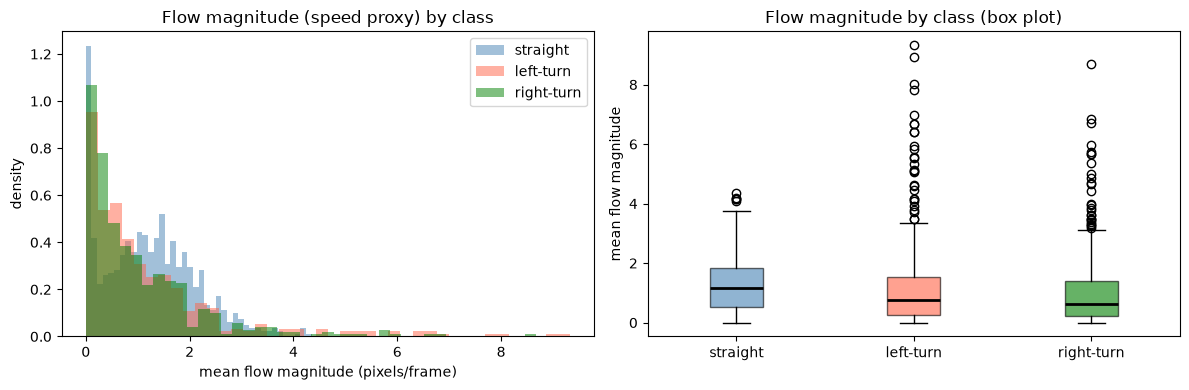


Coarse speed thresholds (valid sequences only):
  slow   < 0.51 px/frame
  medium   0.51 to 1.39 px/frame
  fast   > 1.39 px/frame

  straight      slow=0.25  fast=0.42
  left-turn     slow=0.37  fast=0.29
  right-turn    slow=0.43  fast=0.25


In [15]:
flow_mag_col = framediff_3c[:, flow_offset + FLOW_KEYS.index('flow_mag_mean')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for cls in CLASSES:
    ax.hist(flow_mag_col[labels_3c == cls], bins=40, alpha=0.5,
            color=COLORS[cls], label=cls, density=True)
ax.set_xlabel('mean flow magnitude (pixels/frame)')
ax.set_ylabel('density')
ax.set_title('Flow magnitude (speed proxy) by class')
ax.legend()

ax2 = axes[1]
data = [flow_mag_col[labels_3c == c] for c in CLASSES]
bp = ax2.boxplot(data, tick_labels=CLASSES, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
for patch, cls in zip(bp['boxes'], CLASSES):
    patch.set_facecolor(COLORS[cls]); patch.set_alpha(0.6)
ax2.set_title('Flow magnitude by class (box plot)')
ax2.set_ylabel('mean flow magnitude')

plt.tight_layout()
plt.savefig('outputs/framediff_v2_speed_distribution.png', dpi=140)
plt.show()

# coarse speed breakdown
valid_mags = flow_mag_col[valid_3c]
slow_thresh = np.percentile(valid_mags, 33)
fast_thresh = np.percentile(valid_mags, 66)
print(f'\nCoarse speed thresholds (valid sequences only):')
print(f'  slow   < {slow_thresh:.2f} px/frame')
print(f'  medium   {slow_thresh:.2f} to {fast_thresh:.2f} px/frame')
print(f'  fast   > {fast_thresh:.2f} px/frame')
print()
for cls in CLASSES:
    mask = labels_3c == cls
    slow_frac = (flow_mag_col[mask] < slow_thresh).mean()
    fast_frac = (flow_mag_col[mask] > fast_thresh).mean()
    print(f'  {cls:12s}  slow={slow_frac:.2f}  fast={fast_frac:.2f}')

x-axis: flow_x_mean   y-axis: flow_mag_bottom


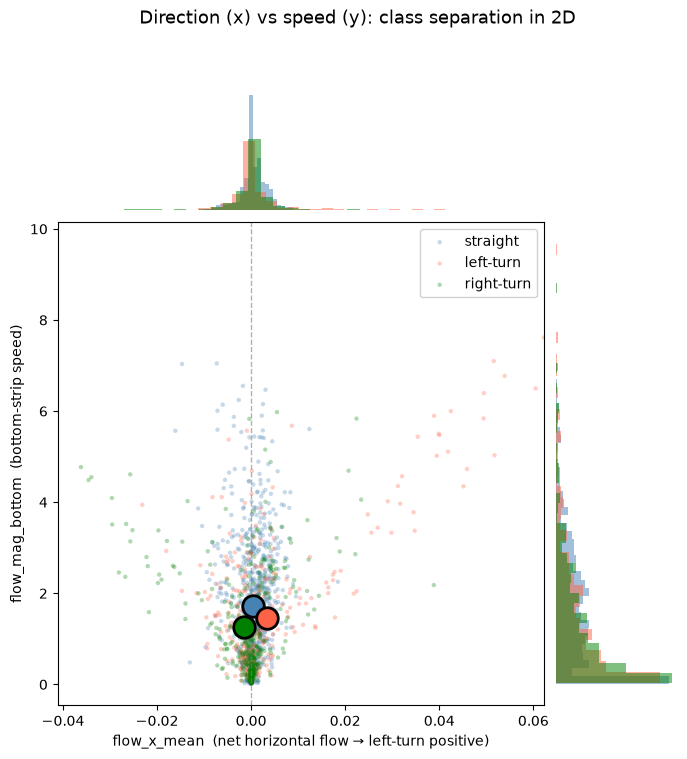


Balanced 5-fold CV accuracy (3-class):
  direction only (flow_x_mean)   : 0.343
  speed only     (flow_mag_bottom)   : 0.389
  combined                       : 0.452
  chance                         : 0.333


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- resolve the two feature columns by name (robust to the exact FLOW_KEYS spelling) ---
def flow_col(substr):
    key = next(k for k in FLOW_KEYS if substr in k)
    return framediff_3c[:, flow_offset + FLOW_KEYS.index(key)], key

x_all, xkey = flow_col('x_mean')      # net horizontal flow  -> "which way"
y_all, ykey = flow_col('mag_bottom')  # bottom-strip speed   -> "how fast / is it a turn"
print(f"x-axis: {xkey}   y-axis: {ykey}")   # sanity-check the resolved keys

m = valid_3c
x, y, lab = x_all[m], y_all[m], labels_3c[m]

# --- 2D scatter with marginal densities ---
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      wspace=0.04, hspace=0.04)
ax    = fig.add_subplot(gs[1, 0])
axt   = fig.add_subplot(gs[0, 0], sharex=ax)
axr   = fig.add_subplot(gs[1, 1], sharey=ax)

for cls in CLASSES:
    c = lab == cls
    ax.scatter(x[c], y[c], s=10, alpha=0.30, color=COLORS[cls],
               edgecolors='none', label=cls)
    axt.hist(x[c], bins=40, density=True, color=COLORS[cls], alpha=0.5)
    axr.hist(y[c], bins=40, density=True, color=COLORS[cls], alpha=0.5,
             orientation='horizontal')

# class centroids (big outlined dots) — this is where the separation shows
for cls in CLASSES:
    c = lab == cls
    ax.scatter(x[c].mean(), y[c].mean(), s=240, color=COLORS[cls],
               edgecolors='black', linewidths=2, zorder=5)

ax.axvline(0, color='gray', lw=1, ls='--', alpha=0.6)
ax.set_xlabel(f'{xkey}  (net horizontal flow → left-turn positive)')
ax.set_ylabel(f'{ykey}  (bottom-strip speed)')
lo, hi = np.percentile(x, [1, 99])
ax.set_xlim(1.6 * lo, 1.6 * hi)
ax.legend(loc='upper right', framealpha=0.9)
axt.axis('off'); axr.axis('off')
fig.suptitle('Direction (x) vs speed (y): class separation in 2D', fontsize=13)
plt.savefig('outputs/framediff_v2_2d_separation.png', dpi=140, bbox_inches='tight')
plt.show()

# --- how much do you actually gain by combining? ---
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

cls_to_i = {c: i for i, c in enumerate(CLASSES)}
yenc = np.array([cls_to_i[c] for c in lab])

def cv_bal_acc(*cols):
    X = np.column_stack(cols)
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=1000, class_weight='balanced'))
    return cross_val_score(clf, X, yenc, cv=5, scoring='balanced_accuracy').mean()

print("\nBalanced 5-fold CV accuracy (3-class):")
print(f"  direction only ({xkey})   : {cv_bal_acc(x):.3f}")
print(f"  speed only     ({ykey})   : {cv_bal_acc(y):.3f}")
print(f"  combined                       : {cv_bal_acc(x, y):.3f}")
print(f"  chance                         : {1/len(CLASSES):.3f}")

In [20]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("FLOW_KEYS:", FLOW_KEYS)
print(f"flow block = cols {flow_offset}..{flow_offset+len(FLOW_KEYS)-1} of "
      f"{framediff_3c.shape[1]} total\n")

m = valid_3c
cls_to_i = {c: i for i, c in enumerate(CLASSES)}
yenc = np.array([cls_to_i[c] for c in labels_3c[m]])

def cv_acc(X):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, class_weight='balanced'))
    return cross_val_score(clf, X, yenc, cv=5, scoring='balanced_accuracy').mean()

def col(key):
    return framediff_3c[m, flow_offset + FLOW_KEYS.index(key)]

def find(sub):
    hits = [k for k in FLOW_KEYS if sub in k]
    return hits[0] if hits else None

# (1) single-feature CV screen — the honest test vs. ANOVA
print("Per-feature balanced CV accuracy (single feature), ranked:")
ranked = sorted(((k, cv_acc(col(k))) for k in FLOW_KEYS), key=lambda r: -r[1])
for k, a in ranked:
    print(f"  {k:24s} {a:.3f}")
print(f"  {'chance':24s} {1/len(CLASSES):.3f}\n")

# (2) feature-set combos
flow_all = framediff_3c[m, flow_offset:flow_offset + len(FLOW_KEYS)]
combos = {
    "means baseline (x_mean + mag_bottom)":
        [find('x_mean'), find('mag_bottom')],
    "moment proxy (last_lr_balance + mag_p75)":
        [find('last'), find('mag_p75')],
}
print("Feature-set balanced CV accuracy:")
for name, keys in combos.items():
    keys = [k for k in keys if k]
    if keys:
        X = np.column_stack([col(k) for k in keys])
        print(f"  {name:44s} {cv_acc(X):.3f}   ({', '.join(keys)})")
print(f"  {'ALL flow features':44s} {cv_acc(flow_all):.3f}")
print(f"  {'ALL framediff features (trend+flow)':44s} {cv_acc(framediff_3c[m]):.3f}")
print(f"  {'chance':44s} {1/len(CLASSES):.3f}")

FLOW_KEYS: ['flow_mag_mean', 'flow_mag_p75', 'flow_lr_balance', 'flow_x_mean', 'flow_y_mean', 'flow_mag_bottom']
flow block = cols 10..15 of 22 total

Per-feature balanced CV accuracy (single feature), ranked:
  flow_y_mean              0.419
  flow_mag_p75             0.389
  flow_mag_bottom          0.389
  flow_lr_balance          0.371
  flow_mag_mean            0.371
  flow_x_mean              0.343
  chance                   0.333

Feature-set balanced CV accuracy:
  means baseline (x_mean + mag_bottom)         0.452   (flow_x_mean, flow_mag_bottom)
  moment proxy (last_lr_balance + mag_p75)     0.389   (flow_mag_p75)
  ALL flow features                            0.452
  ALL framediff features (trend+flow)          0.468
  chance                                       0.333


In [21]:
yenc = np.array([{c: i for i, c in enumerate(CLASSES)}[c] for c in labels_3c[m]])
last_offset = flow_offset + len(FLOW_KEYS)          # last_flow block starts here (col 16)
meancol = lambda k: framediff_3c[m, flow_offset + FLOW_KEYS.index(k)]
lastcol = lambda k: framediff_3c[m, last_offset + FLOW_KEYS.index(k)]

print("last_flow single-feature CV:")
for k in FLOW_KEYS:
    print(f"  last_{k:16s} {cv_acc(lastcol(k).reshape(-1,1)):.3f}")

print(f"\nflow_x direction — mean vs last (turn moment):")
print(f"  mean : {cv_acc(meancol('flow_x_mean').reshape(-1,1)):.3f}")
print(f"  last : {cv_acc(lastcol('flow_x_mean').reshape(-1,1)):.3f}")

print(f"\ncombos vs 0.452 baseline:")
print(f"  mean(x)+mean(bottom)          : {cv_acc(np.column_stack([meancol('flow_x_mean'), meancol('flow_mag_bottom')])):.3f}")
print(f"  last(x)+last(bottom)          : {cv_acc(np.column_stack([lastcol('flow_x_mean'), lastcol('flow_mag_bottom')])):.3f}")
print(f"  mean+last (x, bottom) 4 feats : {cv_acc(np.column_stack([meancol('flow_x_mean'), meancol('flow_mag_bottom'), lastcol('flow_x_mean'), lastcol('flow_mag_bottom')])):.3f}")

last_flow single-feature CV:
  last_flow_mag_mean    0.376
  last_flow_mag_p75     0.397
  last_flow_lr_balance  0.374
  last_flow_x_mean      0.363
  last_flow_y_mean      0.436
  last_flow_mag_bottom  0.395

flow_x direction — mean vs last (turn moment):
  mean : 0.343
  last : 0.363

combos vs 0.452 baseline:
  mean(x)+mean(bottom)          : 0.452
  last(x)+last(bottom)          : 0.481
  mean+last (x, bottom) 4 feats : 0.453


In [22]:
import os, time
PEAK_PATH = os.path.join(FEATURES_DIR, 'framediff_v2_peak_flow.npy')
PEAK_SEQ  = os.path.join(FEATURES_DIR, 'framediff_v2_peak_flow_seqids.npy')

if not os.path.exists(PEAK_PATH):
    entries = [(sid, e) for sid, e in manifest.items() if e['label'] in CLASSES]
    peak_list, seq_list, t0 = [], [], time.time()
    for i, (sid, entry) in enumerate(entries):
        fnames = entry['context_fnames']; n = len(fnames)
        if n >= 2:
            imgs = [load_frame(fn) for fn in fnames]
            flow_pairs = np.array([[compute_optical_flow(imgs[j], imgs[j+1])[k]
                                    for k in FLOW_KEYS] for j in range(n-1)])
            idx = np.argmax(np.abs(flow_pairs), axis=0)          # strongest-flow pair, per key
            peak = flow_pairs[idx, np.arange(flow_pairs.shape[1])]
        else:
            peak = np.zeros(len(FLOW_KEYS), np.float32)
        peak_list.append(peak.astype(np.float32)); seq_list.append(sid)
        if (i+1) % 200 == 0:
            el = time.time()-t0; print(f"  {i+1}/{len(entries)} ({el:.0f}s, ~{el/(i+1)*(len(entries)-i-1):.0f}s left)")
    np.save(PEAK_PATH, np.array(peak_list, np.float32)); np.save(PEAK_SEQ, np.array(seq_list))
    print("saved", np.array(peak_list).shape)

peak_arr = np.load(PEAK_PATH)
peak_seq = np.load(PEAK_SEQ, allow_pickle=True).astype(str)
plook = {s: i for i, s in enumerate(peak_seq)}
peak_3c = peak_arr[np.array([plook[s] for s in seq_ids_3c])]
peakcol = lambda k: peak_3c[m, FLOW_KEYS.index(k)]

print("\npeak single-feature CV:")
for k in FLOW_KEYS:
    print(f"  peak_{k:16s} {cv_acc(peakcol(k).reshape(-1,1)):.3f}")
print(f"\nflow_x  mean / last / peak head-to-head:")
print(f"  mean : {cv_acc(meancol('flow_x_mean').reshape(-1,1)):.3f}")
print(f"  last : {cv_acc(lastcol('flow_x_mean').reshape(-1,1)):.3f}")
print(f"  peak : {cv_acc(peakcol('flow_x_mean').reshape(-1,1)):.3f}")
print(f"\npeak(x)+mean(bottom) : {cv_acc(np.column_stack([peakcol('flow_x_mean'), meancol('flow_mag_bottom')])):.3f}   (vs 0.452 baseline)")

  200/1604 (20s, ~141s left)
  400/1604 (39s, ~117s left)
  600/1604 (62s, ~104s left)
  800/1604 (87s, ~87s left)
  1000/1604 (107s, ~65s left)
  1200/1604 (129s, ~43s left)
  1400/1604 (151s, ~22s left)
  1600/1604 (175s, ~0s left)
saved (1604, 6)

peak single-feature CV:
  peak_flow_mag_mean    0.337
  peak_flow_mag_p75     0.332
  peak_flow_lr_balance  0.343
  peak_flow_x_mean      0.367
  peak_flow_y_mean      0.351
  peak_flow_mag_bottom  0.343

flow_x  mean / last / peak head-to-head:
  mean : 0.343
  last : 0.363
  peak : 0.367

peak(x)+mean(bottom) : 0.437   (vs 0.452 baseline)


## Cell 9 — Visual QA: optical flow overlaid on frames

Generating optical flow visual QA panel (2-row, speed-focused)...


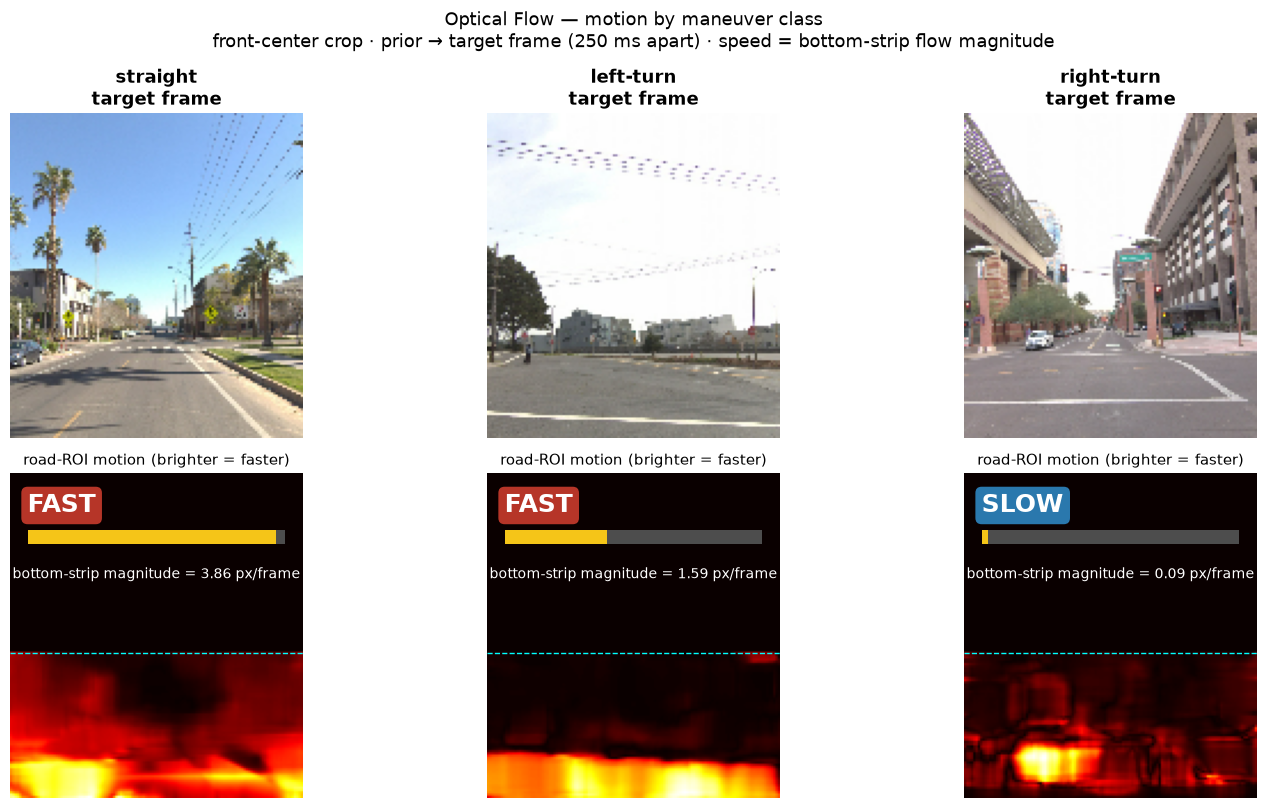

Saved outputs/framediff_v2_flow_visual_qa.png


In [34]:
print('Generating optical flow visual QA panel (2-row, speed-focused)...')
from matplotlib.patches import Rectangle

def get_qa_pair(cls):
    """Return (img_prev, img_curr, sid) for a class example with n_context >= 2."""
    for sid, entry in manifest.items():
        if entry['label'] == cls and entry['n_context'] >= 2:
            fnames = entry['context_fnames']
            return load_frame(fnames[-2]), load_frame(fnames[-1]), sid
    return None, None, None

def speed_tag(bottom):
    # thresholds = your coarse 33rd / 66th percentiles of bottom-strip magnitude
    if bottom > 1.39:   return 'FAST',   '#c0392b'
    if bottom >= 0.51:  return 'MEDIUM', '#e08e0b'
    return 'SLOW', '#2c7fb8'

MAX_BAR = 4.0  # full bar = 4 px/frame, for at-a-glance comparison across columns

fig, axes = plt.subplots(2, len(CLASSES), figsize=(5 * len(CLASSES), 8.2))

for i, cls in enumerate(CLASSES):
    img_prev, img_curr, sid = get_qa_pair(cls)
    if img_prev is None:
        for row in range(2): axes[row, i].axis('off')
        continue

    x0, x1 = CENTER_SEG
    prev_crop = img_prev[:, x0:x1, :]
    curr_crop = img_curr[:, x0:x1, :]
    H, W = prev_crop.shape[:2]

    prev_gray = cv2.cvtColor(prev_crop, cv2.COLOR_RGB2GRAY)
    curr_gray = cv2.cvtColor(curr_crop, cv2.COLOR_RGB2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, curr_gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
    mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    fq = compute_optical_flow(img_prev, img_curr)
    bottom = fq['flow_mag_bottom']
    tag, tcol = speed_tag(bottom)

    # ---- Row 0: target frame ----
    axes[0, i].imshow(curr_crop)
    axes[0, i].set_title(f'{cls}\ntarget frame', fontsize=13, fontweight='bold')
    axes[0, i].axis('off')

    # ---- Row 1: road-ROI motion (speed proxy) ----
    ax = axes[1, i]
    road_y = int(H * 0.55)                 # matches compute_optical_flow road_region_frac
    mag_display = mag.copy(); mag_display[:road_y, :] = 0
    ax.imshow(mag_display, cmap='hot')
    ax.axhline(road_y, color='cyan', linewidth=1, linestyle='--')
    ax.set_title('road-ROI motion (brighter = faster)', fontsize=11)
    ax.axis('off')

    # speed tag + magnitude bar, drawn over the dark top region for contrast
    ax.text(0.06, 0.90, tag, transform=ax.transAxes, ha='left', va='center',
            fontsize=18, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.25', fc=tcol, ec='none', alpha=0.95))
    frac = min(bottom / MAX_BAR, 1.0)
    ax.add_patch(Rectangle((0.06, 0.78), 0.88, 0.045, transform=ax.transAxes,
                           fc='0.30', ec='none'))
    ax.add_patch(Rectangle((0.06, 0.78), 0.88 * frac, 0.045, transform=ax.transAxes,
                           fc='#f5c518', ec='none'))
    ax.text(0.5, 0.71, f'bottom-strip magnitude = {bottom:.2f} px/frame',
            transform=ax.transAxes, ha='center', va='top', fontsize=10, color='white')

plt.suptitle('Optical Flow — motion by maneuver class\n'
             'front-center crop · prior → target frame (250 ms apart) · '
             'speed = bottom-strip flow magnitude', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/framediff_v2_flow_visual_qa.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved outputs/framediff_v2_flow_visual_qa.png')

## Cell 10 — Feature distribution box plots

IndexError: index 5 is out of bounds for axis 1 with size 5

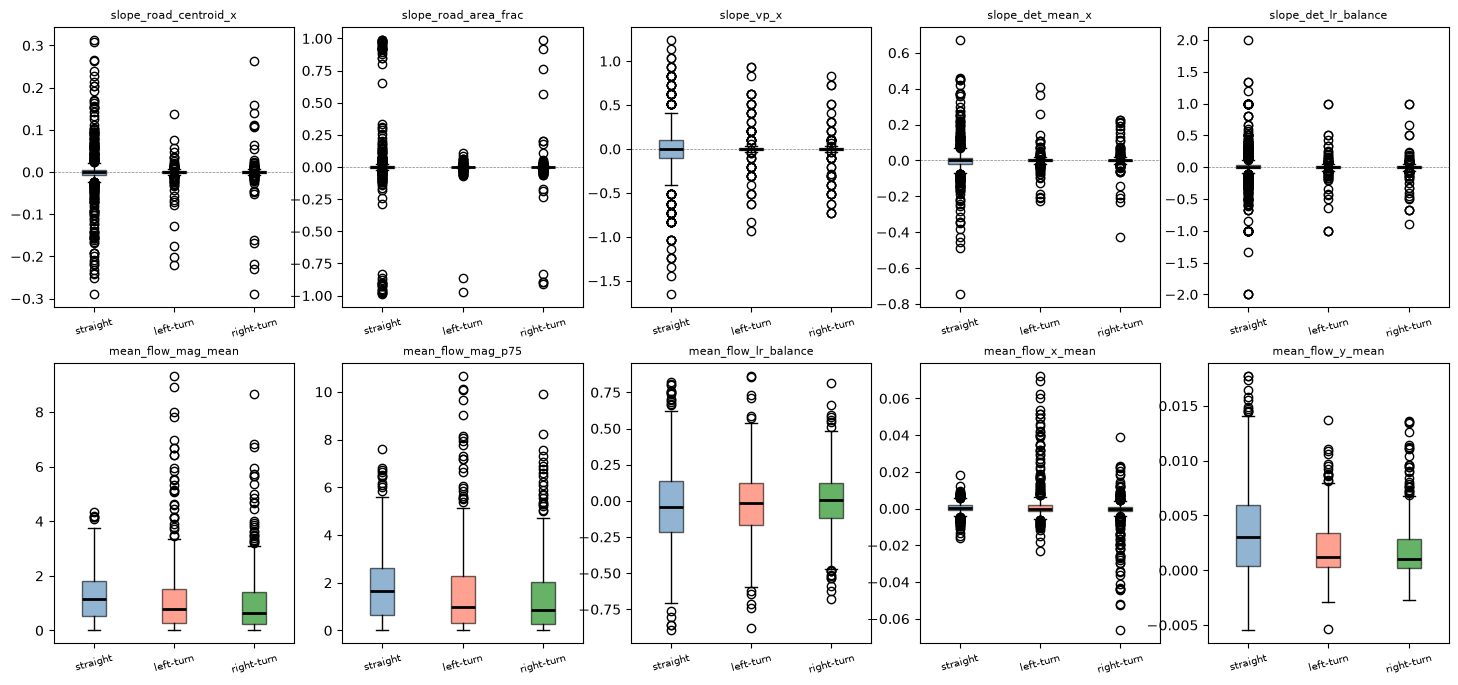

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# top row: trend slope dims
for fi, k in enumerate(TREND_KEYS[:5]):
    ax = axes[0, fi]
    col = framediff_3c[:, fi]
    data = [col[labels_3c == c] for c in CLASSES]
    bp = ax.boxplot(data, tick_labels=CLASSES, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], CLASSES):
        patch.set_facecolor(COLORS[cls]); patch.set_alpha(0.6)
    ax.set_title(k, fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=15)
    ax.axhline(0, color='gray', lw=0.5, ls='--')

# bottom row: mean flow dims
for fi, k in enumerate(FLOW_KEYS):
    ax = axes[1, fi]
    col = framediff_3c[:, flow_offset + fi]
    data = [col[labels_3c == c] for c in CLASSES]
    bp = ax.boxplot(data, tick_labels=CLASSES, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], CLASSES):
        patch.set_facecolor(COLORS[cls]); patch.set_alpha(0.6)
    ax.set_title(f'mean_{k}', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=15)

plt.suptitle('framediff v2 — Feature Distributions by Class\n'
             'top: trend slopes  |  bottom: mean optical flow', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/framediff_v2_distributions.png', dpi=140)
plt.show()
print('Saved outputs/framediff_v2_distributions.png')

## Cell 11 — Benchmark

In [44]:
hog_3c  = _load_and_align('hog.npy',  seq_ids_orig)
yolo_3c = _load_and_align('yolo.npy', seq_ids_orig)
hsv_3c  = _load_and_align('hsv.npy',  seq_ids_orig)

# or simply use X_final_3class as hog_3c directly since it's 5796 dims
hog_3c = x_final

print(f'hog_3c:  {getattr(hog_3c,  "shape", "NONE")}')
print(f'yolo_3c: {getattr(yolo_3c, "shape", "NONE")}')
print(f'hsv_3c:  {getattr(hsv_3c,  "shape", "NONE")}')

hog_3c:  (1604, 5796)
yolo_3c: (1604, 32)
hsv_3c:  (1604, 34)


In [47]:
# ── Cell 11 — Benchmark ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.decomposition import PCA

trend_only_3c = framediff_3c[:, :len(TREND_KEYS)]
flow_only_3c  = framediff_3c[:, len(TREND_KEYS):]

benchmark_sets = {
    'Trend_only':              trend_only_3c,
    'Flow_only':               flow_only_3c,
    'Trend+Flow':              framediff_3c,
    'YOLO+Trend+Flow':         np.concatenate([yolo_3c,    framediff_3c], axis=1),
    'Road_v2+Trend+Flow':      np.concatenate([road_v2_3c, framediff_3c], axis=1),
    'YOLO+Road_v2+Trend+Flow': np.concatenate([yolo_3c, road_v2_3c,
                                                framediff_3c], axis=1),
    'HOG+Trend+Flow':          np.concatenate([hog_3c,    framediff_3c], axis=1),
    'HOG+Flow_only':           np.concatenate([hog_3c,    flow_only_3c], axis=1),
    'All+Trend+Flow':          np.concatenate([hog_3c, hsv_3c, yolo_3c,
                                               road_v2_3c, framediff_3c], axis=1),
    'All+Flow_only':           np.concatenate([hog_3c, hsv_3c, yolo_3c,
                                               road_v2_3c, flow_only_3c], axis=1),
}

majority_baseline = pd.Series(labels_3c).value_counts(normalize=True).max()
print(f'Majority-class baseline: {majority_baseline:.3f}')
print(f'Prior best (All_v2Road+BEV_Corridor / SVM): 0.555\n')

bench_rows  = []
preds_store = {}

for name, feats in benchmark_sets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        feats, labels_3c, test_size=0.25,
        random_state=RANDOM_STATE, stratify=labels_3c)
    sc = StandardScaler()
    X_tr_s, X_te_s = sc.fit_transform(X_tr), sc.transform(X_te)

    svm = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)
    svm.fit(X_tr_s, y_tr); svm_pred = svm.predict(X_te_s)

    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr, y_tr); rf_pred = rf.predict(X_te)

    for mname, pred in [('SVM', svm_pred), ('RF', rf_pred)]:
        acc = accuracy_score(y_te, pred)
        mf1 = f1_score(y_te, pred, labels=CLASSES, average='macro', zero_division=0)
        bench_rows.append({'feature_set': name, 'model': mname,
                            'accuracy': acc, 'macro_f1': mf1})
        preds_store[(name, mname)] = (y_te, pred)

    _svm_f1 = f1_score(y_te, svm_pred, labels=CLASSES, average='macro', zero_division=0)
    _rf_f1  = f1_score(y_te, rf_pred,  labels=CLASSES, average='macro', zero_division=0)
    print(f'{name:30s}  '
          f'SVM acc={accuracy_score(y_te, svm_pred):.3f} f1={_svm_f1:.3f}  |  '
          f'RF  acc={accuracy_score(y_te, rf_pred):.3f} f1={_rf_f1:.3f}')

bench_df = pd.DataFrame(bench_rows)
bench_df.to_csv(os.path.join(FEATURES_DIR,
                              'benchmark_framediff_v2_3class.csv'), index=False)
best = bench_df.loc[bench_df['macro_f1'].idxmax()]
print(f'\nBest: {best["feature_set"]} / {best["model"]}  '
      f'acc={best["accuracy"]:.3f}  macro_f1={best["macro_f1"]:.3f}')
print(f'Delta vs prior best (0.555): {best["macro_f1"] - 0.555:+.3f}')
print('Saved benchmark_framediff_v2_3class.csv')

Majority-class baseline: 0.464
Prior best (All_v2Road+BEV_Corridor / SVM): 0.555

Trend_only                      SVM acc=0.469 f1=0.458  |  RF  acc=0.591 f1=0.543
Flow_only                       SVM acc=0.556 f1=0.496  |  RF  acc=0.594 f1=0.541
Trend+Flow                      SVM acc=0.569 f1=0.540  |  RF  acc=0.648 f1=0.587
YOLO+Trend+Flow                 SVM acc=0.499 f1=0.455  |  RF  acc=0.638 f1=0.575
Road_v2+Trend+Flow              SVM acc=0.539 f1=0.505  |  RF  acc=0.636 f1=0.567
YOLO+Road_v2+Trend+Flow         SVM acc=0.536 f1=0.496  |  RF  acc=0.646 f1=0.583
HOG+Trend+Flow                  SVM acc=0.601 f1=0.548  |  RF  acc=0.594 f1=0.511
HOG+Flow_only                   SVM acc=0.606 f1=0.553  |  RF  acc=0.606 f1=0.536
All+Trend+Flow                  SVM acc=0.594 f1=0.540  |  RF  acc=0.616 f1=0.538
All+Flow_only                   SVM acc=0.596 f1=0.544  |  RF  acc=0.594 f1=0.518

Best: Trend+Flow / RF  acc=0.648  macro_f1=0.587
Delta vs prior best (0.555): +0.032
Saved benchm

## Cell 12 — Confusion matrix + PCA

In [35]:
best_name  = best['feature_set']
best_model = best['model']
y_te_b, y_pr_b = preds_store[(best_name, best_model)]
cm = confusion_matrix(y_te_b, y_pr_b, labels=CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix\n{best_name} / {best_model}')
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

ax2 = axes[1]
proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(
    StandardScaler().fit_transform(framediff_3c))
for cls in CLASSES:
    mask = labels_3c == cls
    ax2.scatter(proj[mask, 0], proj[mask, 1],
                c=COLORS[cls], label=cls, alpha=0.4, s=10)
ax2.set_title('PCA — Trend + Flow (all 22 dims)')
ax2.legend(fontsize=8)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('outputs/framediff_v2_confusion_pca.png', dpi=140)
plt.show()

print(classification_report(y_te_b, y_pr_b, labels=CLASSES, zero_division=0))
print('Saved outputs/framediff_v2_confusion_pca.png')

NameError: name 'best' is not defined

## Cell 13 — Save aligned arrays for use in `feature_pipeline_v3_3class.ipynb`

In [28]:
np.save(os.path.join(FEATURES_DIR, 'framediff_v2_3c_aligned.npy'), framediff_3c)
np.save(os.path.join(FEATURES_DIR, 'framediff_v2_trend_3c.npy'),   framediff_3c[:, :len(TREND_KEYS)])
np.save(os.path.join(FEATURES_DIR, 'framediff_v2_flow_3c.npy'),    framediff_3c[:, len(TREND_KEYS):])
np.save(os.path.join(FEATURES_DIR, 'framediff_v2_valid_3c.npy'),   valid_3c)

print('Saved:')
print(f'  framediff_v2_3c_aligned.npy   shape={framediff_3c.shape}  (22 dims)')
print(f'  framediff_v2_trend_3c.npy     shape={framediff_3c[:, :len(TREND_KEYS)].shape}  (10 dims)')
print(f'  framediff_v2_flow_3c.npy      shape={framediff_3c[:, len(TREND_KEYS):].shape}  (12 dims)')
print(f'  framediff_v2_valid_3c.npy     (bool — True where n_context >= 2)')
print('\n=== framediff_v2_3class complete ===')

Saved:
  framediff_v2_3c_aligned.npy   shape=(1604, 22)  (22 dims)
  framediff_v2_trend_3c.npy     shape=(1604, 10)  (10 dims)
  framediff_v2_flow_3c.npy      shape=(1604, 12)  (12 dims)
  framediff_v2_valid_3c.npy     (bool — True where n_context >= 2)

=== framediff_v2_3class complete ===


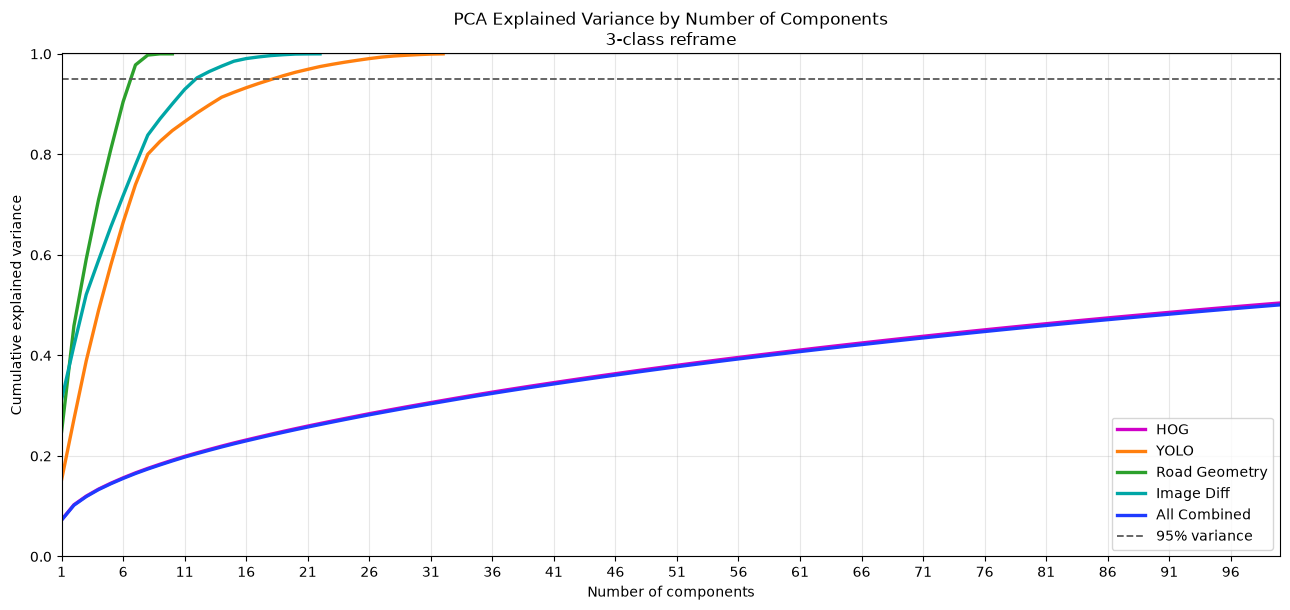

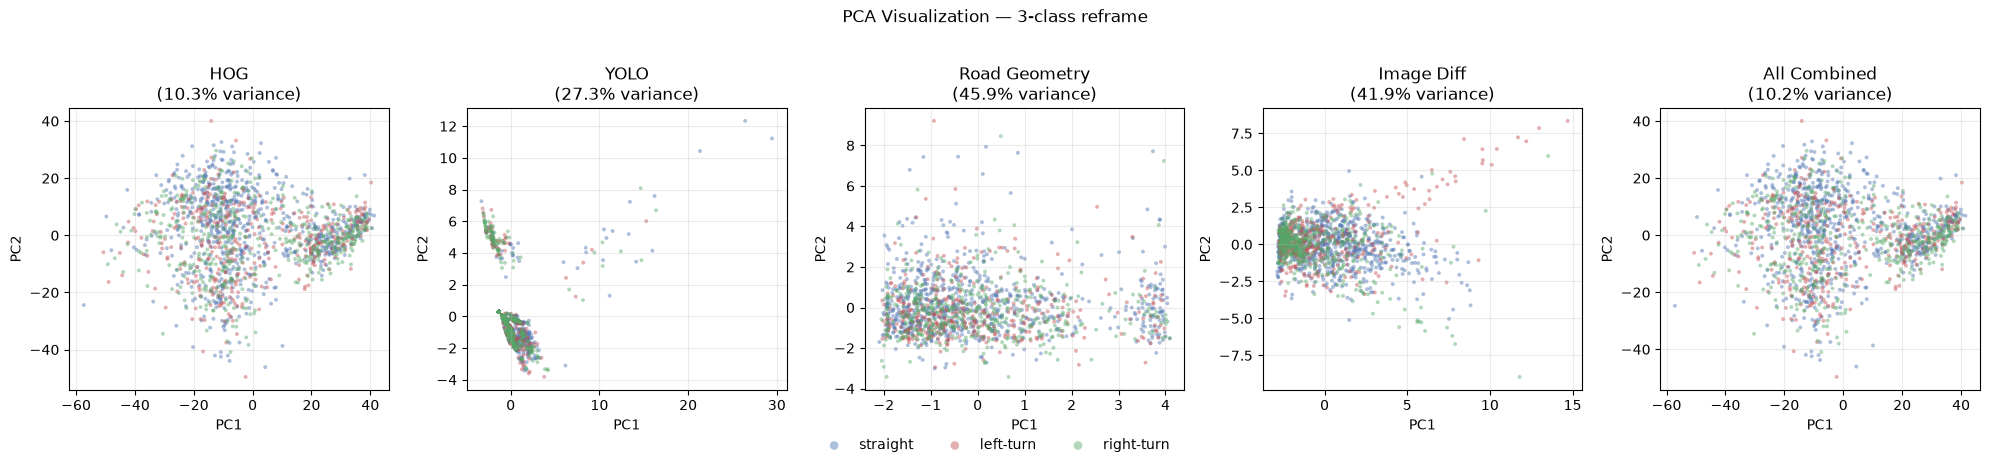

In [30]:
# ============================================================
# 3-class PCA visualizations (day + night) from real features
# Families: HOG, YOLO, Road Geometry, Image-Diff (frame-diff)  [HSV dropped]
# ============================================================
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# locate the features dir (reuse FEATURES_DIR if your notebook already set it)
try:
    FEATURES_DIR
except NameError:
    _root = Path.cwd(); _root = _root if (_root / 'data').exists() else _root.parent
    FEATURES_DIR = _root / 'data' / 'processed' / 'waymo_e2e' / 'features'
FEATURES_DIR = Path(FEATURES_DIR)
L = lambda f: np.load(FEATURES_DIR / f, allow_pickle=True)

# --- targets + align HOG/YOLO (full extraction) to the 1,604 three-class seqs ---
seq3 = L('seq_ids_3class.npy').astype(str)
lab3 = L('labels_3class.npy').astype(str)
seqf = L('seq_ids.npy').astype(str)                 # full extraction order (2,037)
assert np.isin(seq3, seqf).all(), "some 3-class seq_ids missing from the full set"
idx  = np.array([{s: i for i, s in enumerate(seqf)}[s] for s in seq3])

HOG   = np.load(FEATURES_DIR / 'hog.npy')[idx]      # full HOG  -> 3-class subset (day+night)
YOLO  = np.load(FEATURES_DIR / 'yolo.npy')[idx]     # full YOLO -> 3-class subset
ROAD  = L('road_v2_3class.npy')                     # already 1,604, aligned to seq_ids_3class
IMD   = L('framediff_v2_3class.npy')                # frame-diff features, 1,604
valid = L('framediff_v2_3class_valid.npy')          # drop invalid frame-diff rows in its panels

feature_sets = {'HOG': HOG, 'YOLO': YOLO, 'Road Geometry': ROAD, 'Image Diff': IMD}
feature_sets['All Combined'] = np.concatenate([HOG, YOLO, ROAD, IMD], axis=1)
ORDER = ['HOG', 'YOLO', 'Road Geometry', 'Image Diff', 'All Combined']
FCOL  = {'HOG': '#d000c8', 'YOLO': '#ff7f0e', 'Road Geometry': '#2ca02c',
         'Image Diff': '#00a6a6', 'All Combined': '#1f3bff'}
CCOL  = {'straight': '#4c72b0', 'left-turn': '#c44e52', 'right-turn': '#55a868'}
MAXC  = 100

def fit_pca(X, n):
    Xs = StandardScaler().fit_transform(np.asarray(X, np.float32))
    rank = min(Xs.shape[0] - 1, Xs.shape[1]); nc = min(n, rank)
    solver = 'full' if nc == rank else 'randomized'
    return PCA(n_components=nc, svd_solver=solver, random_state=42).fit(Xs), Xs

# --- Figure 1: cumulative explained variance (the critical chart) ---
fig, ax = plt.subplots(figsize=(13, 6.2))
for name in ORDER:
    p, _ = fit_pca(feature_sets[name], MAXC)
    cv = np.cumsum(p.explained_variance_ratio_)
    ax.plot(np.arange(1, len(cv) + 1), cv, color=FCOL[name], lw=2.4, label=name)
ax.axhline(0.95, ls='--', color='0.35', lw=1.3, label='95% variance')
ax.set_xlim(1, MAXC); ax.set_ylim(0, 1.001)
ax.set_xlabel('Number of components'); ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA Explained Variance by Number of Components\n3-class reframe')
ax.set_xticks(range(1, 101, 5)); ax.grid(alpha=0.3); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'pca_explained_variance_3class.png', dpi=150, facecolor='white')
plt.show()

# --- Figure 2: PCA(2) scatter grid, colored by the 3 classes ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4.3))
for ax, name in zip(axes, ORDER):
    X = feature_sets[name]
    m = valid if name in ('Image Diff', 'All Combined') else np.ones(len(X), bool)
    p, Xs = fit_pca(X[m], 2); Z = p.transform(Xs); lv = lab3[m]
    for cls in ['straight', 'left-turn', 'right-turn']:
        c = lv == cls
        ax.scatter(Z[c, 0], Z[c, 1], s=8, alpha=0.45, color=CCOL[cls], edgecolors='none', label=cls)
    ax.set_title(f'{name}\n({p.explained_variance_ratio_[:2].sum():.1%} variance)')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.grid(alpha=0.25)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=3, markerscale=2.2, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('PCA Visualization — 3-class reframe', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'pca_scatter_3class.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

## IPM + BEV corridor combinations



In [48]:
# ── IPM + BEV corridor combinations with Trend+Flow ──────────────────────────
ipm_3c       = np.load(os.path.join(FEATURES_DIR, 'ipm_3class.npy'))
bev_corr_3c  = np.load(os.path.join(FEATURES_DIR, 'bev_corridor_3class.npy'))

print(f'ipm_3c:      {ipm_3c.shape}')
print(f'bev_corr_3c: {bev_corr_3c.shape}')

extended_sets = {
    'Trend+Flow':                  framediff_3c,
    'Trend+Flow+IPM':              np.concatenate([framediff_3c, ipm_3c], axis=1),
    'Trend+Flow+BEV':              np.concatenate([framediff_3c, bev_corr_3c], axis=1),
    'Trend+Flow+IPM+BEV':          np.concatenate([framediff_3c, ipm_3c,
                                                    bev_corr_3c], axis=1),
    'Flow+IPM':                    np.concatenate([flow_only_3c, ipm_3c], axis=1),
    'Flow+BEV':                    np.concatenate([flow_only_3c, bev_corr_3c], axis=1),
    'Flow+IPM+BEV':                np.concatenate([flow_only_3c, ipm_3c,
                                                    bev_corr_3c], axis=1),
}

print(f'\nMajority-class baseline: {majority_baseline:.3f}')
print(f'Current best (Trend+Flow / RF): 0.587\n')

ext_rows  = []
preds_ext = {}

for name, feats in extended_sets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        feats, labels_3c, test_size=0.25,
        random_state=RANDOM_STATE, stratify=labels_3c)
    sc = StandardScaler()
    X_tr_s, X_te_s = sc.fit_transform(X_tr), sc.transform(X_te)

    svm = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)
    svm.fit(X_tr_s, y_tr); svm_pred = svm.predict(X_te_s)

    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr, y_tr); rf_pred = rf.predict(X_te)

    for mname, pred in [('SVM', svm_pred), ('RF', rf_pred)]:
        acc = accuracy_score(y_te, pred)
        mf1 = f1_score(y_te, pred, labels=CLASSES, average='macro', zero_division=0)
        ext_rows.append({'feature_set': name, 'model': mname,
                          'accuracy': acc, 'macro_f1': mf1})
        preds_ext[(name, mname)] = (y_te, pred)

    _svm_f1 = f1_score(y_te, svm_pred, labels=CLASSES, average='macro', zero_division=0)
    _rf_f1  = f1_score(y_te, rf_pred,  labels=CLASSES, average='macro', zero_division=0)
    print(f'{name:30s}  '
          f'SVM f1={_svm_f1:.3f}  |  RF f1={_rf_f1:.3f}')

ext_df  = pd.DataFrame(ext_rows)
best_ext = ext_df.loc[ext_df['macro_f1'].idxmax()]
print(f'\nBest extended: {best_ext["feature_set"]} / {best_ext["model"]}  '
      f'macro_f1={best_ext["macro_f1"]:.3f}')
print(f'Delta vs Trend+Flow/RF (0.587): {best_ext["macro_f1"] - 0.587:+.3f}')

ext_df.to_csv(os.path.join(FEATURES_DIR,
                            'benchmark_framediff_ipm_bev_3class.csv'), index=False)
print('Saved benchmark_framediff_ipm_bev_3class.csv')

ipm_3c:      (1604, 8)
bev_corr_3c: (1604, 7)

Majority-class baseline: 0.464
Current best (Trend+Flow / RF): 0.587

Trend+Flow                      SVM f1=0.540  |  RF f1=0.587
Trend+Flow+IPM                  SVM f1=0.554  |  RF f1=0.577
Trend+Flow+BEV                  SVM f1=0.527  |  RF f1=0.573
Trend+Flow+IPM+BEV              SVM f1=0.498  |  RF f1=0.588
Flow+IPM                        SVM f1=0.476  |  RF f1=0.536
Flow+BEV                        SVM f1=0.481  |  RF f1=0.520
Flow+IPM+BEV                    SVM f1=0.490  |  RF f1=0.563

Best extended: Trend+Flow+IPM+BEV / RF  macro_f1=0.588
Delta vs Trend+Flow/RF (0.587): +0.001
Saved benchmark_framediff_ipm_bev_3class.csv
